<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões e deformações na flexão pura

### Problema 6

Para a viga AB que se mostra na figura determine a distância $a$ para a qual o valor absoluto máximo do momento fletor na viga é o menor possível e a correspondente tensão normal máxima devida à flexão. Considere que a viga é construída com um perfil laminado IPE100 e que $\sigma_\textrm{adm}$ = 275 MPa.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P6/MSII_Au04_P6.png"
style="max-height: 100%; max-width: 100%;"/>

#### Dados do problema

In [14]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()
IPE100 = varin()

d.CD = 0.45 # unit: m
d.DE = 0.63 # unit: m
d.EB = 0.27 # unit: m
d.P1 = 4. # unit: kN
d.P2 = 6. # unit: kN

d.CE = d.CD + d.DE
d.CB = d.CE + d.EB

d.sigadm = 275. # unit: MPa

IPE100.Iz = 183.*1e6 # mm4
IPE100.bf = 290. # mm - largura do banzo
IPE100.Wz = (1260.*1e3)*1e-9 # m³ - largura do banzo

### Resolução

- Equilíbrio estático: cálculo das reações em função do parâmetro $a$

In [15]:
rc, rb, a = sy.symbols('rc rb a')

def printsym(expr):
    return expr.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

sumFy = -d.P1 - 2*d.P2 + rc + rb
print(f'System of Equations:\n--------------------\nsumFy = 0 : {sumFy} = 0')
sumMC = d.P1*(a) - d.P2*(d.CD) - d.P2*(d.CE) + rb*(d.CB)
print(f'sumMC = 0 : {sumMC} = 0')
sol = solve({sumFy,sumMC},{rc, rb})

print(f'\nSolution:\n---------')
RC = sol[rc]
print(f'RA = {printsym(RC)} [kN]')
RB = sol[rb]
print(f'RB = {printsym(RB)} [kN]')

System of Equations:
--------------------
sumFy = 0 : rb + rc - 16.0 = 0
sumMC = 0 : 4.0*a + 1.35*rb - 9.18 = 0

Solution:
---------
RA = 2.963*a + 9.2 [kN]
RB = 6.8 - 2.963*a [kN]


- Diagrama de esforços: esforço transverso

In [16]:
vab, vcd, vde, veb = sy.symbols('vab vcd vde veb')

EQ_V_AC = - d.P1 - vab
EQ_V_CD = - d.P1 + rc - vcd
EQ_V_DE = - d.P1 + rc -d.P2 - vde
EQ_V_EB = - d.P1 + rc -2*d.P2 - veb

VAC = solve(EQ_V_AC,vab)[0]
print(f'VAC(x) = {VAC:.1f} [kN]')
VCD = solve(EQ_V_CD,vcd)[0]
print(f'VCD(x) = {VCD} = {printsym(VCD.subs({(rc,RC)}))} [kN]')
VDE = solve(EQ_V_DE,vde)[0]
print(f'VDE(x) = {VDE} = {printsym(VDE.subs({(rc,RC)}))} [kN]')
VEB = solve(EQ_V_EB,veb)[0]
print(f'VEB(x) = {VEB} = {printsym(VEB.subs({(rc,RC)}))} [kN]')

VAC(x) = -4.0 [kN]
VCD(x) = rc - 4.0 = 2.963*a + 5.2 [kN]
VDE(x) = rc - 10.0 = 2.963*a - 0.8 [kN]
VEB(x) = rc - 16.0 = 2.963*a - 6.8 [kN]


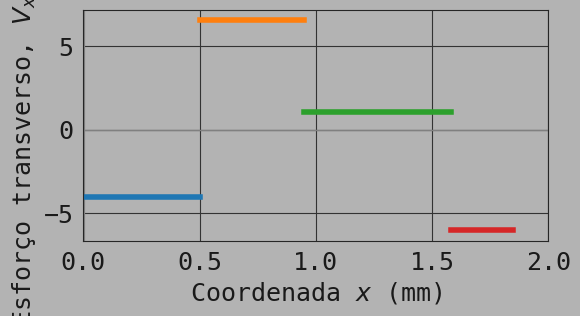

In [17]:
from ipywidgets import interactive

def vplot(aa):

    d.AC = aa
    d.AD = d.AC + d.CD
    d.AE = d.AD + d.DE
    d.AB = d.AC + d.CD + d.DE + d.EB

    xAC = np.linspace(0,d.AC)
    xCD = np.linspace(d.AC,d.AD)
    xDE = np.linspace(d.AD,d.AE)
    xEB = np.linspace(d.AE,d.AB)

    def sy2array(sygunc,xlist):
        scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
        vector_func = np.vectorize(scalar_func)
        return vector_func(xlist)

    VAC_a = VAC.subs({(rc,RC)})
    VCD_a = VCD.subs({(rc,RC)})
    VDE_a = VDE.subs({(rc,RC)})
    VEB_a = VEB.subs({(rc,RC)})

    yVAC = VAC_a.subs({(a,d.AC)})*np.ones(len(xAC))
    yVCD = VCD_a.subs({(a,d.CD)})*np.ones(len(xCD))
    yVDE = VDE_a.subs({(a,d.DE)})*np.ones(len(xDE))
    yVEB = VEB_a.subs({(a,d.EB)})*np.ones(len(xEB))

    # PLOTS
    fz = 14

    fig, ax = plt.subplots(figsize=(6,3))
    plt.axhline(linewidth=1,color=(.5, .5, .5))
    plt.axvline(linewidth=3,color=(.5, .5, .5))
    # -
    plt.plot(xAC,yVAC,linewidth=4) # plt.fill_between(xAC,yVAC, facecolor='r', alpha=.3, interpolate=True)
    plt.plot(xCD,yVCD,linewidth=4) # plt.fill_between(xCD,yVCD, alpha=.3)
    plt.plot(xDE,yVDE,linewidth=4) # plt.fill_between(xDE,yVDE, alpha=.3)
    plt.plot(xEB,yVEB,linewidth=4) # plt.fill_between(xEB,yVEB, alpha=.3)
    plt.xlabel('Coordenada $x$ (mm)')
    plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
    plt.xlim(0,d.AB*1.05)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    xrang = np.round(np.arange(0,d.AB*1.1, 0.5),2)
    ax.set_xticks(xrang)
    ax.set_xticklabels([i for i in xrang])
    # plt.ylim(-int(P4.p2*2),int(P4.p2*2))
    plt.grid(True)
    plt.show()

vplot(.5) # select a given valur for a

In [18]:
interactive_plot = interactive(vplot, aa=(0.01, 1))
output = interactive_plot.children[-1]
output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=0.505, description='aa', max=1.0, min=0.01), Output(layout=Layout(heig…

- Diagrama de esforços: momento fletor

In [19]:
mab, mcd, mde, meb, x = sy.symbols('mab mcd mde meb x')

d.AC = a
d.AD = d.AC + d.CD
d.AE = d.AD + d.DE

EQ_M_AC = d.P1*x + mab
EQ_M_CD = d.P1*x - rc*(x-d.AC) + mcd
EQ_M_DE = d.P1*x - rc*(x-d.AC) + d.P2*(x-d.AD) + mde
EQ_M_EB = d.P1*x - rc*(x-d.AC) + d.P2*(x-d.AD) + d.P2*(x-d.AE) + meb

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

MAC = solve(EQ_M_AC,mab)[0]
print(f'MAC(x) = {MAC} [kN.m]')
MCD = solve(EQ_M_CD,mcd)[0]
print(f'MCD(x) = {MCD} \n       = {printsymSF(MCD.subs({(rc,RC)}))} [kN.m]')
MDE = solve(EQ_M_DE,mde)[0]
print(f'MDE(x) = {MDE} \n       = {printsymSF(MDE.subs({(rc,RC)}))} [kN.m]')
MEB = solve(EQ_M_EB,meb)[0]
print(f'MEB(x) = {MEB} \n       = {printsymSF(MEB.subs({(rc,RC)}))} [kN.m]')

MAC(x) = -4.0*x [kN.m]
MCD(x) = -a*rc + rc*x - 4.0*x 
       = -2.96296296296296*a**2 + 2.963*a*x - 9.2*a + 5.2*x [kN.m]
MDE(x) = -a*rc + 6.0*a + rc*x - 10.0*x + 2.7 
       = -2.96296296296296*a**2 + 2.96296296296296*a*x - 3.2*a - 0.8*x + 2.7 [kN.m]
MEB(x) = -a*rc + 12.0*a + rc*x - 16.0*x + 9.18 
       = -2.96296296296296*a**2 + 2.96296296296296*a*x + 2.8*a - 6.8*x + 9.18 [kN.m]


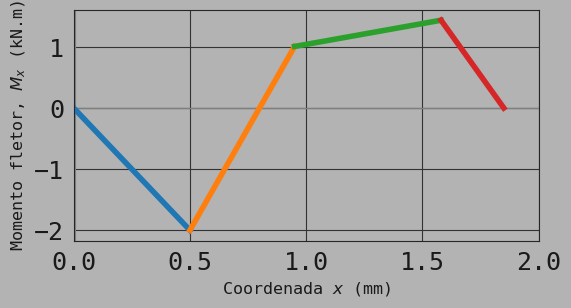

In [20]:
from ipywidgets import interactive

def mplot(aa):

    d.AC = aa
    d.AD = d.AC + d.CD
    d.AE = d.AD + d.DE
    d.AB = d.AC + d.CD + d.DE + d.EB

    xAC = np.linspace(0,d.AC)
    xCD = np.linspace(d.AC,d.AD)
    xDE = np.linspace(d.AD,d.AE)
    xEB = np.linspace(d.AE,d.AB)

    def sy2array(sygunc,xlist):
        scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
        vector_func = np.vectorize(scalar_func)
        return vector_func(xlist)

    MAC_a = MAC.subs({(rc,RC)})
    MCD_a = MCD.subs({(rc,RC)})
    MDE_a = MDE.subs({(rc,RC)})
    MEB_a = MEB.subs({(rc,RC)})

    yMAC = sy2array(MAC_a.subs({(a,d.AC)}),xAC) #
    yMCD = sy2array(MCD_a.subs({(a,d.AC)}),xCD) #
    yMDE = sy2array(MDE_a.subs({(a,d.AC)}),xDE) #
    yMEB = sy2array(MEB_a.subs({(a,d.AC)}),xEB) #

    # PLOTS
    fz = 14

    fig, ax = plt.subplots(figsize=(6,3))
    plt.axhline(linewidth=1,color=(.5, .5, .5))
    plt.axvline(linewidth=3,color=(.5, .5, .5))
    # -
    plt.plot(xAC,yMAC,linewidth=4) # plt.fill_between(xAC,yVAC, facecolor='r', alpha=.3, interpolate=True)
    plt.plot(xCD,yMCD,linewidth=4) # plt.fill_between(xCD,yVCD, alpha=.3)
    plt.plot(xDE,yMDE,linewidth=4) # plt.fill_between(xDE,yVDE, alpha=.3)
    plt.plot(xEB,yMEB,linewidth=4) # plt.fill_between(xEB,yVEB, alpha=.3)
    plt.xlabel('Coordenada $x$ (mm)', fontsize=12)
    plt.ylabel('Momento fletor, $M_{x}$ (kN.m)', fontsize=12)
    plt.xlim(0,d.AB*1.05)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    xrang = np.round(np.arange(0,d.AB*1.1, 0.5),2)
    ax.set_xticks(xrang)
    ax.set_xticklabels([i for i in xrang])
    # plt.ylim(-int(P4.p2*2),int(P4.p2*2))
    plt.grid(True)
    plt.show()

mplot(.5) # select a given valur for a
# note:
# a = 0.1 - the maximum moment occur at xC
# a = 0.5 - the maximum moment occur at xE

In [21]:
interactive_plot = interactive(mplot, aa=(0.01, 1))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=0.505, description='aa', max=1.0, min=0.01), Output(layout=Layout(heig…

- A condição para a qual o valor absoluto máximo do momento fletor na viga é o menor possível deve verificar umas das seguintes condições:

\begin{equation*}
|M^{\textrm{max}}(x_C)| = |M^{\textrm{max}}(x_D)|
\quad\vee\quad
|M^{\textrm{max}}(x_C)| = |M^{\textrm{max}}(x_E)|
\end{equation*}

In [22]:
MC_max = MAC.subs({(rc,RC),(x,a)})
print(f'MC = {MC_max}')

MD_max = MCD.subs({(rc,RC),(x,a+d.CD)})
print(f'MD = {sy.factor(MD_max)}')

ME_max = MDE.subs({(rc,RC),(x,a+d.CD+d.DE)})
print(f'ME = {sy.factor(ME_max)}')

MC = -4.0*a
MD = -2.66666666666667*(1.0*a - 0.8775)
ME = -1.836*(0.435729847494554*a - 1.0)


\begin{equation*}
|M^{\textrm{max}}(x_C)| = |M^{\textrm{max}}(x_D)|
\end{equation*}

In [23]:
EQ1 = -MC_max - MD_max
# the negative value is to account for absolute values
print(f'EQ1 = {sy.factor(EQ1)}')
print(':::::::::::::::::::::::::::::::::::::::')
a_sol1 = solve(EQ1,a)[0]
print(f'a_sol1 = {a_sol1:.3f}')
print('--------------')
MC_max_a_sol1 = np.abs(MC_max.subs({(a,a_sol1)}))
print(f'MC_max_a_sol1 = {MC_max_a_sol1:.3f} [kN.m]')
MD_max_a_sol1 = np.abs(MD_max.subs({(a,a_sol1)}))
print(f'MD_max_a_sol1 = {MD_max_a_sol1:.3f} [kN.m]')
ME_max_a_sol1 = np.abs(ME_max.subs({(a,a_sol1)}))
print(f'ME_max_a_sol1 = {ME_max_a_sol1:.3f} [kN.m]')

EQ1 = 6.66666666666667*(1.0*a - 0.351)
:::::::::::::::::::::::::::::::::::::::
a_sol1 = 0.351
--------------
MC_max_a_sol1 = 1.404 [kN.m]
MD_max_a_sol1 = 1.404 [kN.m]
ME_max_a_sol1 = 1.555 [kN.m]


\begin{equation*}
|M^{\textrm{max}}(x_C)| = |M^{\textrm{max}}(x_E)|
\end{equation*}

In [24]:
EQ2 = -MC_max - ME_max
print(f'EQ2 = {-MC_max} + {printsymSF(-ME_max)} = {sy.factor(EQ2)} = 0')

print('::::::::::::::')
a_sol2 = solve(EQ2,a)[0]
print(f'a_sol2 = {a_sol2:.3f}')
print('::::::::::::::')
MC_max_a_sol2 = np.abs(MC_max.subs({(a,a_sol2)}))
print(f'MC_max_a_sol2 = {MC_max_a_sol2:.3f} [kN.m]')
MD_max_a_sol2 = np.abs(MD_max.subs({(a,a_sol2)}))
print(f'MD_max_a_sol2 = {MD_max_a_sol2:.3f} [kN.m]')
ME_max_a_sol2 = np.abs(ME_max.subs({(a,a_sol2)}))
print(f'ME_max_a_sol2 = {ME_max_a_sol2:.3f} [kN.m]')

EQ2 = 4.0*a + 0.8*a - 1.836 = 4.8*(1.0*a - 0.3825) = 0
::::::::::::::
a_sol2 = 0.382
::::::::::::::
MC_max_a_sol2 = 1.530 [kN.m]
MD_max_a_sol2 = 1.320 [kN.m]
ME_max_a_sol2 = 1.530 [kN.m]


- O segundo cenário $M(x_C) = M(x_D)$ conduz a um valor mínimo do momento fletor máximo de 1.530 [kN.m]

In [25]:
mlist1 = [MC_max_a_sol1,MD_max_a_sol1,ME_max_a_sol1]
mlist2 = [MC_max_a_sol2,MD_max_a_sol2,ME_max_a_sol2]
mom_maxmin = np.min([np.max(mlist1),np.max(mlist2)])
print(f'Mom min. = {mom_maxmin:.3f} [kN.m]')


Mom min. = 1.530 [kN.m]


- Resulta um módulo resistente:

\begin{equation*}
W_\textrm{min} = \frac{M_f^\textrm{max}}{\sigma_\textrm{adm}}
\end{equation*}

In [26]:

W = (mom_maxmin*1e3)/(d.sigadm*1e6)
print(f'W = {W:.3e} [m³] = {W*1e9:.3e} [mm³]')

W = 5.564e-6 [m³] = 5.564e+3 [mm³]


- Por consulta, pode-se escolher o perfil IPE80 com $W_z = 20.0\times 10^{3}$ m $^3$.

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>